# DroneRF Signal Characterization (Notebook 02)

## Objective
To characterize the statistical and signal-processing properties of representative RF recordings from the DroneRF dataset before any preprocessing or feature extraction.

## Research Question
What are the statistical and signal-processing characteristics of the representative RF recordings before any preprocessing?

## Methodology
- Utilize pre-computed metadata to prevent redundant filesystem traversals.
- Load exactly one deterministic representative recording per drone class (the smallest valid file to minimize disk I/O).
- Parse only a tightly bounded numeric subset of each signal to preserve memory.
- Evaluate core characteristics systematically: validation, time-domain behavior, distribution, stationarity, autocorrelation, and frequency-domain behavior.

## 2. Configuration

**Why are we performing this step?**
To define global constants governing subset loading, statistical windows, and visualization parameters.

**What do we expect to observe?**
A centralized configuration block establishing the analysis constraints.

**Why is it important?**
Centralization guarantees that variables like `SAMPLE_SIZE` and `MAX_LAGS` remain consistent across all algorithms and avoid hardcoding errors in downstream functions.

In [21]:
# Global Analysis Parameters
SAMPLE_SIZE = 10000        # Data points parsed per representative recording
FS = 1.0                   # Normalized sampling frequency
MAX_LAGS = 50              # Maximum lags for Autocorrelation Analysis
ROLLING_WINDOW = 500       # Window size for Stationarity Inspection
ZOOM_SAMPLES = 200         # Number of samples for detailed time-domain zooming

# Visualization Parameters
DPI = 300                  # Publication-quality figure resolution

## 3. Imports

**Why are we performing this step?**
To load all essential numerical and visualization libraries.

**What do we expect to observe?**
A clean namespace importing `numpy`, `pandas`, `scipy`, `statsmodels`, and plotting utilities.

**Why is it important?**
Optimized C-backends are required to execute complex mathematical characterizations (e.g., PSD, ADF Test) reliably and rapidly.

In [37]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from statsmodels.tsa.stattools import adfuller
from scipy.signal import welch

# Publication-quality visual styling
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings("ignore")

# Path Configuration
sys.path.append(str(Path.cwd().parent))
try:
    from src.utils.paths import PROJECT_ROOT, DATA_DIR, FIGURES_DIR
except ImportError:
    sys.path.append(str(Path.cwd()))
    from src.utils.paths import PROJECT_ROOT, DATA_DIR, FIGURES_DIR

NB_FIGURES_DIR = FIGURES_DIR / "notebook02"
NB_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"[✓] Figures Directory ready: {NB_FIGURES_DIR}")

[✓] Figures Directory ready: /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02


## 4. Load Metadata Cache

**Why are we performing this step?**
To reuse the metadata index generated in Notebook 01.

**What do we expect to observe?**
A pandas DataFrame containing pre-validated file paths, sizes, and drone classifications.

**Why is it important?**
This entirely bypasses redundant filesystem traversals and prevents O(N) execution scaling relative to dataset size.

In [23]:
metadata_path = DATA_DIR / "metadata" / "dronerf_metadata.csv"
if not metadata_path.exists():
    raise FileNotFoundError("Metadata CSV not found. Ensure Notebook 01 has been executed.")

df_metadata = pd.read_csv(metadata_path)
print(f"Loaded metadata cache: {len(df_metadata)} total recordings.")
display(df_metadata.head(3))

Loaded metadata cache: 454 total recordings.


,drone_class,experiment_id,receiver,segment_id,relative_path,file_size_bytes,file_size_mb,is_valid_path
0,AR Drone,Unknown,Unknown,0,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,97107740,92.61,True
1,AR Drone,Unknown,Unknown,0,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,95199575,90.79,True
2,AR Drone,Unknown,Unknown,0,data/raw/DroneRF/unzipped_data/AR Drone/RF Dat...,94304316,89.94,True


## 5. Select Representative Signal per Drone Class

**Why are we performing this step?**
To isolate exactly one recording per drone class for in-depth mathematical characterization.

**What do we expect to observe?**
A deterministic subset DataFrame containing exactly four rows (one for each class), chosen by minimum file size.

**Why is it important?**
Characterizing the entire dataset is computationally prohibitive. A deterministic selection ensures total reproducibility and minimal disk I/O.

In [ ]:
def select_representative_signals(
    df: pd.DataFrame,
    receiver: str = "H",
    segment_id: int = 0,
) -> pd.DataFrame:
    """
    Select one deterministic RF sample per drone class under
    controlled receiver and segment conditions.

    This selection is intended only for exploratory visualization
    and must not be interpreted as representative of the entire class.
    """

    valid_df = df[
        (df["is_valid_path"] == True)
        & (df["receiver"] == receiver)
        & (df["segment_id"].astype(int) == segment_id)
    ].copy()

    if valid_df.empty:
        raise ValueError(
            f"No valid samples found for receiver={receiver}, "
            f"segment_id={segment_id}."
        )

    # Sort deterministically so repeated notebook runs select
    # the same experiment for each class.
    valid_df = valid_df.sort_values(
        ["drone_class", "experiment_id", "relative_path"]
    )

    representative_df = (
        valid_df
        .groupby("drone_class", as_index=False)
        .first()
    )

    return representative_df


rep_signals_df = select_representative_signals(
    df_metadata,
    receiver="H",
    segment_id=0,
)

print(
    f"Selected {len(rep_signals_df)} controlled exploratory RF samples."
)

display(
    rep_signals_df[
        [
            "drone_class",
            "experiment_id",
            "receiver",
            "segment_id",
            "relative_path",
            "file_size_mb",
        ]
    ]
)

ValueError: No valid samples found for receiver=H, segment_id=0.

## 6. Load Representative Signals

**Why are we performing this step?**
To securely load only the bounded numeric subset of the chosen CSVs into memory.

**What do we expect to observe?**
A memory cache `signal_cache` populated with 1D NumPy arrays for each drone class.

**Why is it important?**
Loading 90MB files entirely is unnecessary. Caching a small subset using a fast C-engine prevents Out-of-Memory failures and eliminates repeated disk I/O.

In [26]:
# ============================================================
# Load Representative RF Signal Subsets
# ============================================================

def load_signal_subset(file_path: Path, sample_size: int) -> np.ndarray:
    """
    Load a fixed-size subset of a representative RF recording.

    Parameters
    ----------
    file_path : Path
        Path to the representative RF CSV file.

    sample_size : int
        Number of RF samples to load.

    Returns
    -------
    np.ndarray
        One-dimensional RF signal.
    """

    signal = (
        pd.read_csv(
            file_path,
            header=None,
            nrows=1,
            usecols=range(sample_size),
            dtype=np.float32,
            engine="c",
        )
        .to_numpy(copy=False)
        .ravel()
    )

    if signal.size != sample_size:
        raise ValueError(
            f"Expected {sample_size:,} samples but found {signal.size:,} "
            f"in '{file_path.name}'."
        )

    return signal


# ============================================================
# Cache Representative Signals
# ============================================================

signal_cache = {}

for _, row in rep_signals_df.iterrows():

    drone_class = row["drone_class"]

    signal_path = PROJECT_ROOT / row["relative_path"]

    signal = load_signal_subset(
        signal_path,
        SAMPLE_SIZE
    )

    signal_cache[drone_class] = {
        "metadata": row,
        "path": signal_path,
        "signal": signal,
    }

    print(
        f"[✓] {drone_class:<12}"
        f"Loaded {signal.size:,} samples"
    )

print(f"\nSuccessfully cached {len(signal_cache)} representative RF signals.")

[✓] AR Drone    Loaded 10,000 samples
[✓] Backround RF activitiesLoaded 10,000 samples
[✓] Bepop drone Loaded 10,000 samples
[✓] Phantom droneLoaded 10,000 samples

Successfully cached 4 representative RF signals.


## 7. Signal Validation

**Why are we performing this step?**
To mathematically confirm the numerical integrity of the cached subsets.

**What do we expect to observe?**
A Boolean confirmation that arrays are strictly numeric, devoid of NaNs, and devoid of infinite values.

**Why is it important?**
Silent downstream failures in complex functions (like STFT or Welch's method) occur when non-finite or corrupted data is passed.

In [27]:
def validate_signals(cache):
    validation_records = []
    for drone_class, data in cache.items():
        arr = data["signal"]
        validation_records.append({
            "Drone Class": drone_class,
            "Numeric Datatype": np.issubdtype(arr.dtype, np.number),
            "No NaNs": not np.isnan(arr).any(),
            "No Infs": not np.isinf(arr).any()
        })
    return pd.DataFrame(validation_records)

validation_df = validate_signals(signal_cache)
display(validation_df)

if not validation_df[["Numeric Datatype", "No NaNs", "No Infs"]].all().all():
    raise ValueError("Signal validation failed. Review corrupted numeric data.")

,Drone Class,Numeric Datatype,No NaNs,No Infs
0,AR Drone,True,True,True
1,Backround RF activities,True,True,True
2,Bepop drone,True,True,True
3,Phantom drone,True,True,True


## 8. Signal Statistics

**Why are we performing this step?**
To quantify baseline time-domain energy, power, and distribution shapes.

**What do we expect to observe?**
A unified DataFrame reporting standard deviation, RMS, peak-to-peak amplitude, energy, average power, skewness, kurtosis, and zero-crossing rates.

**Why is it important?**
These fundamental metrics benchmark signal magnitudes, determining the appropriate normalization/scaling techniques required prior to deep learning ingestion.

In [28]:
def compute_signal_statistics(arr):
    if arr.size == 0:
        return {}
    
    mean_val = np.mean(arr)
    zero_crossings = ((arr[:-1] * arr[1:]) < 0).sum()
    
    return {
        "Mean": mean_val,
        "Median": np.median(arr),
        "Minimum": np.min(arr),
        "Maximum": np.max(arr),
        "Std Dev": np.std(arr),
        "Variance": np.var(arr),
        "RMS": np.sqrt(np.mean(arr**2)),
        "Peak": np.max(np.abs(arr)),
        "Peak-to-Peak": np.max(arr) - np.min(arr),
        "Energy": np.sum(arr**2),
        "Average Power": np.mean(arr**2),
        "Skewness": stats.skew(arr),
        "Kurtosis": stats.kurtosis(arr),
        "Zero Crossing Rate": zero_crossings / (arr.size - 1)
    }

stats_dict = {}
for drone_class, data in signal_cache.items():
    stats_dict[drone_class] = compute_signal_statistics(data["signal"])

statistics_df = pd.DataFrame(stats_dict).T
display(statistics_df)

,Mean,Median,Minimum,Maximum,Std Dev,Variance,RMS,Peak,Peak-to-Peak,Energy,Average Power,Skewness,Kurtosis,Zero Crossing Rate
AR Drone,0.0375,0.0,-12.0,9.0,2.454403,6.024094,2.454689,12.0,21.0,60255.0,6.025500,0.020408,0.030056,0.372137
Backround RF activities,0.0594,0.0,-8.0,10.0,2.409413,5.805272,2.410145,10.0,18.0,58088.0,5.808800,0.007570,-0.009959,0.377538
Bepop drone,0.0945,0.0,-8.0,9.0,2.401910,5.769169,2.403768,9.0,17.0,57781.0,5.778100,0.029624,0.032442,0.358136
Phantom drone,0.1810,2.0,-198.0,194.0,57.352280,3289.283936,57.352566,198.0,392.0,32893168.0,3289.316895,-0.081860,-0.006062,0.572057


## 9. Time-Domain Analysis

**Why are we performing this step?**
To visually analyze waveform behavior, transient spikes, and base amplitude levels.

**What do we expect to observe?**
A grid mapping the global waveform subset next to a detailed zoomed waveform capturing micro-level fluctuations.

**Why is it important?**
Visualizing raw time series is the fastest method for detecting high-frequency structural signatures or DC offsets.

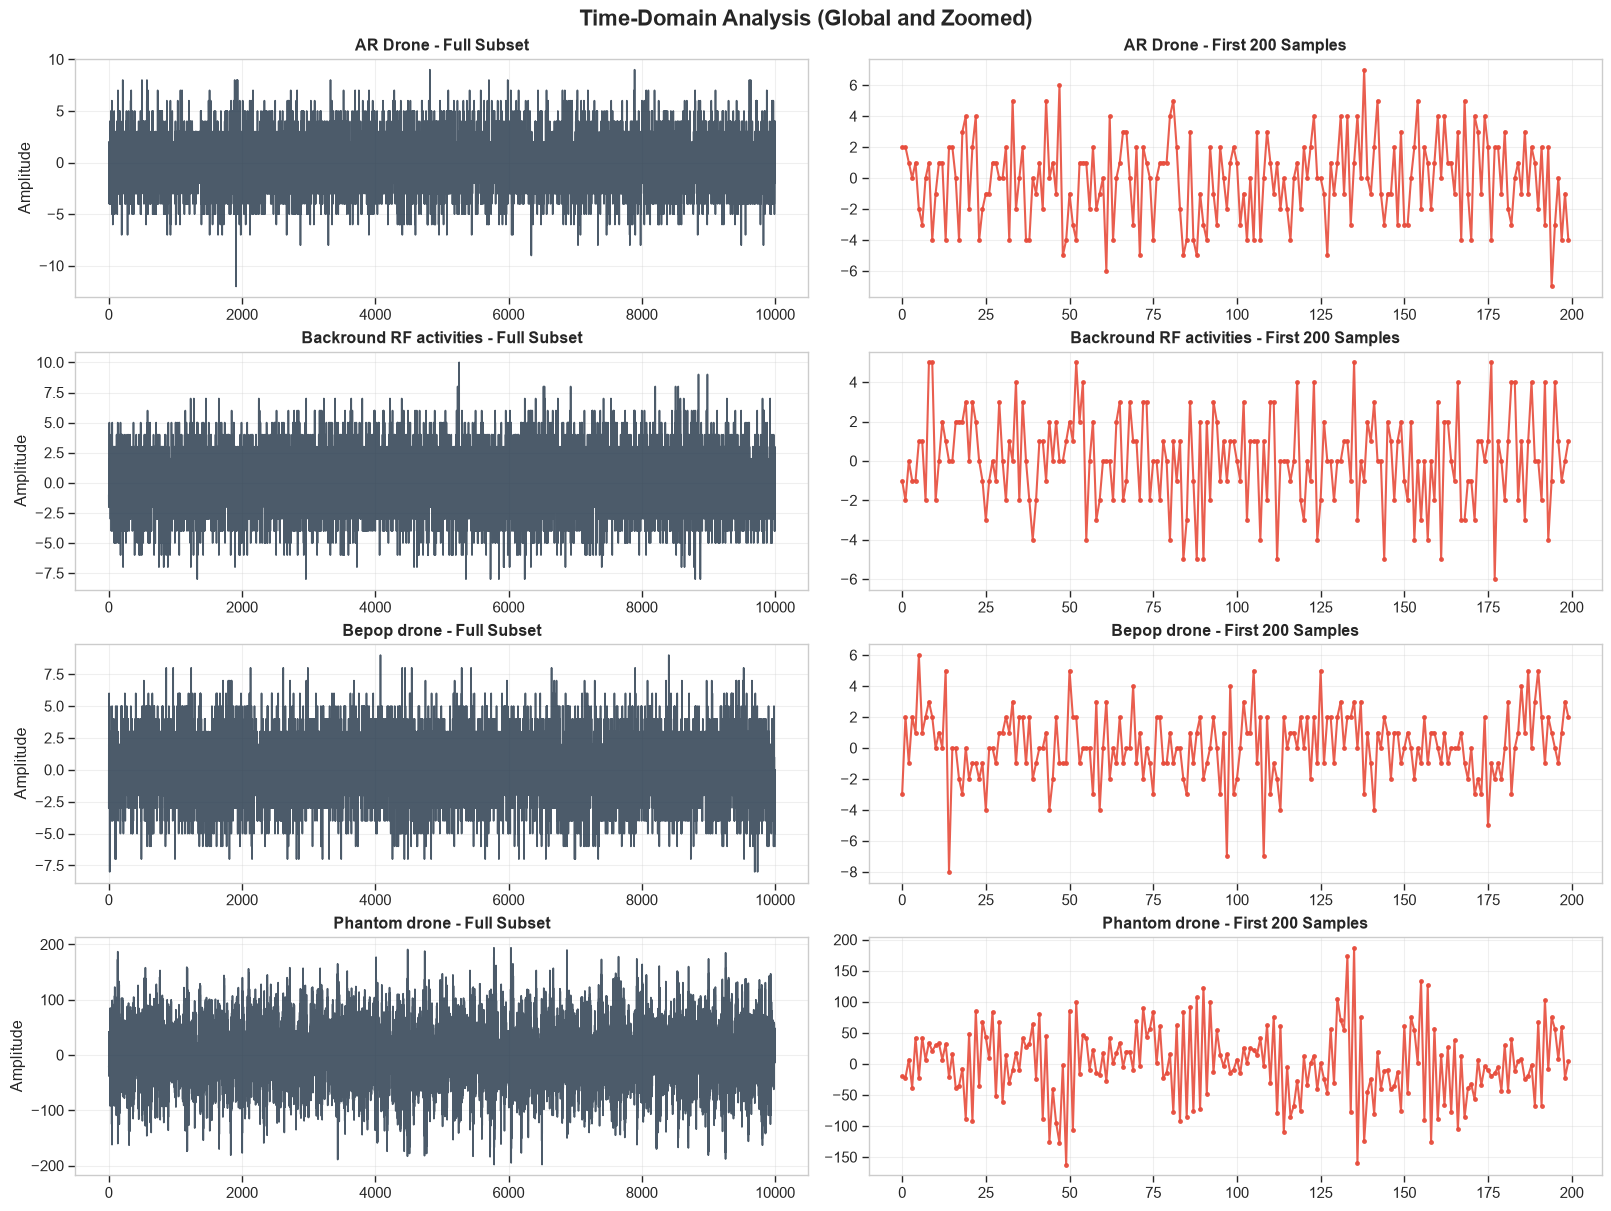

In [29]:
def plot_time_domain(cache, zoom_size, out_dir):
    n_classes = len(cache)
    fig, axes = plt.subplots(n_classes, 2, figsize=(16, 3 * n_classes), constrained_layout=True)
    fig.suptitle("Time-Domain Analysis (Global and Zoomed)", fontsize=16, fontweight="bold")
    
    if n_classes == 1:
        axes = np.array([axes])
        
    for idx, (drone_class, data) in enumerate(cache.items()):
        signal = data["signal"]
        
        # Global Waveform
        axes[idx, 0].plot(signal, color="#2c3e50", alpha=0.85)
        axes[idx, 0].set_title(f"{drone_class} - Full Subset", fontweight="bold")
        axes[idx, 0].set_ylabel("Amplitude")
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Zoomed Waveform
        axes[idx, 1].plot(signal[:zoom_size], color="#e74c3c", marker='.', markersize=5, alpha=0.9, linewidth=1.5)
        axes[idx, 1].set_title(f"{drone_class} - First {zoom_size} Samples", fontweight="bold")
        axes[idx, 1].grid(True, alpha=0.3)
        
    fig_path = out_dir / "time_domain_analysis.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_time_domain(signal_cache, ZOOM_SAMPLES, NB_FIGURES_DIR)

## 10. Distribution Analysis

**Why are we performing this step?**
To analyze the probability distribution and symmetry of RF signal amplitudes.

**What do we expect to observe?**
Histograms, Empirical Cumulative Distribution Functions (ECDF), and grouped Boxplots representing amplitude spread.

**Why is it important?**
Non-Gaussian distributions with heavy tails strongly influence the choice of loss functions and scaling techniques in neural networks.

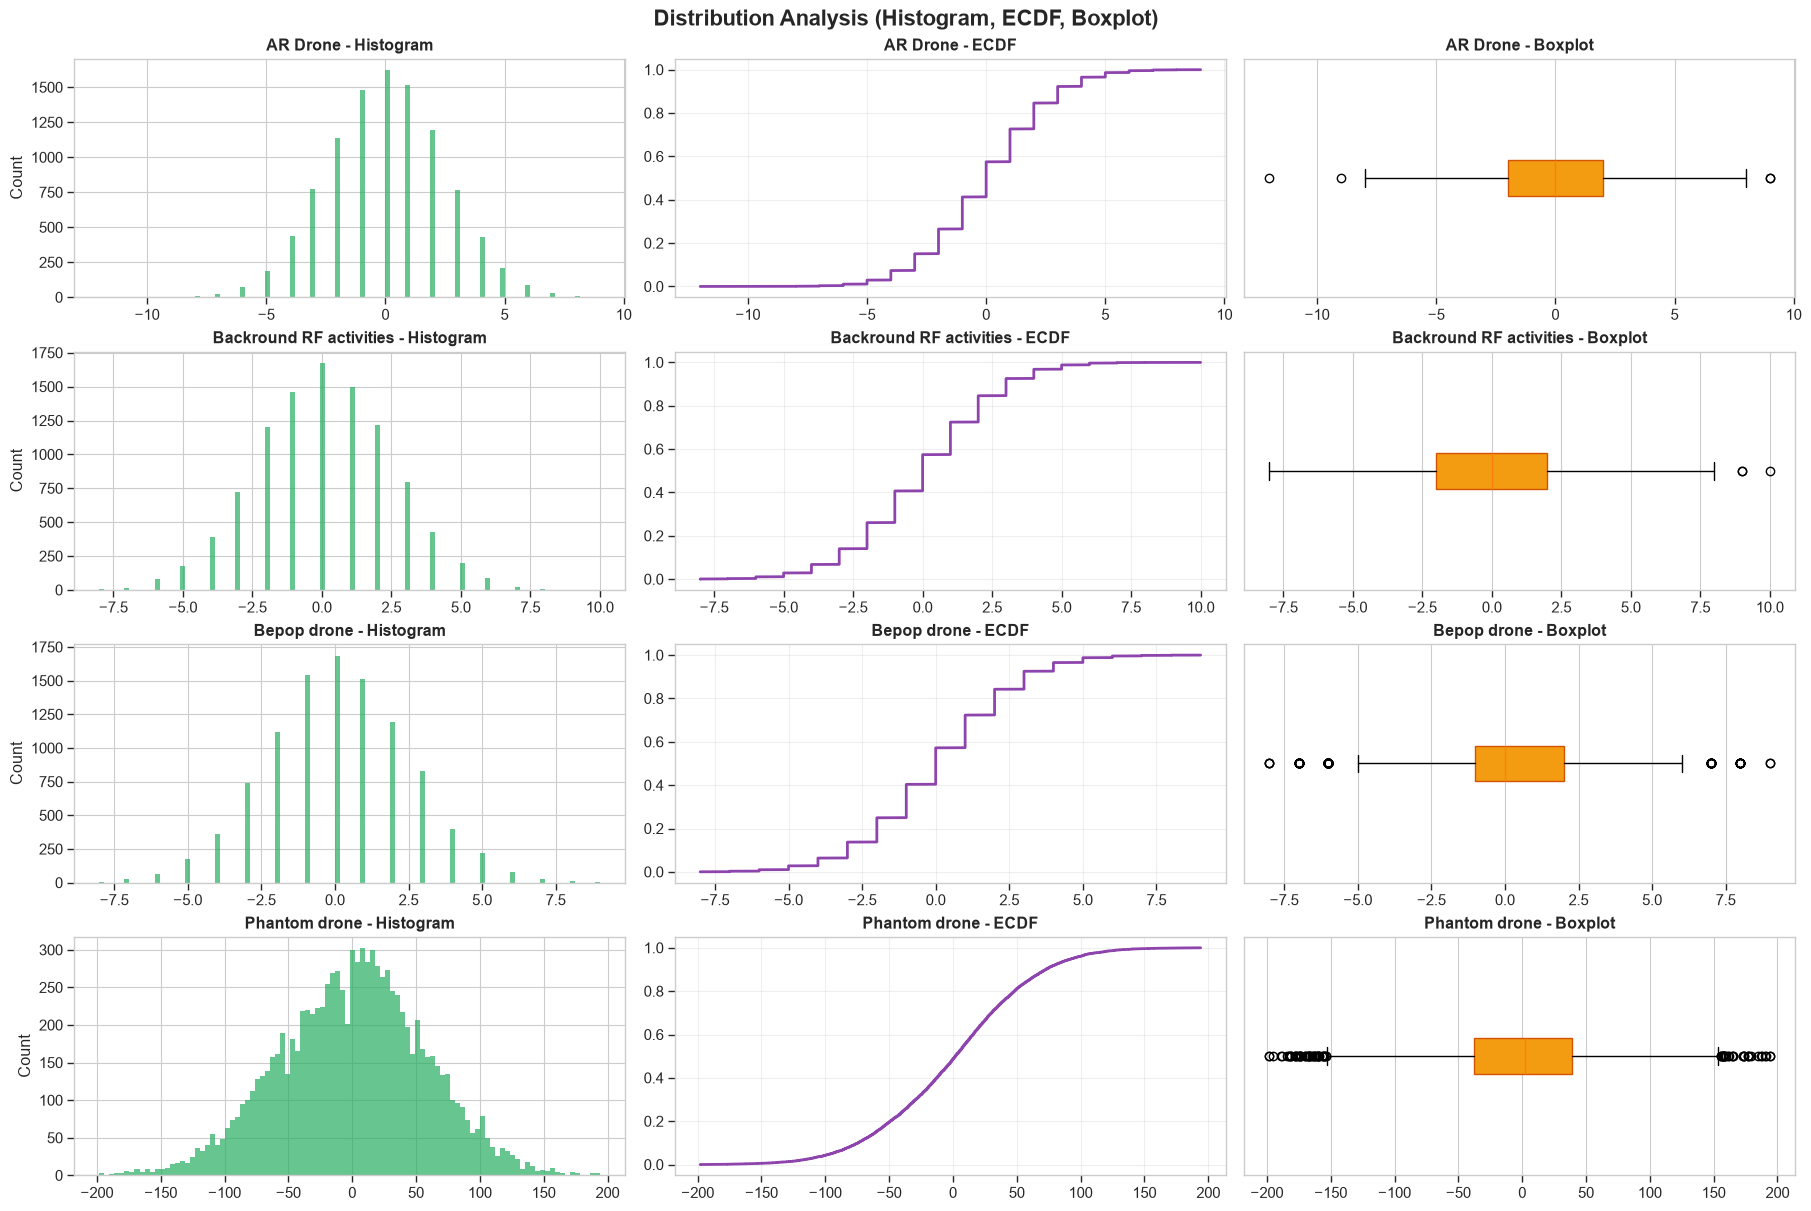

In [30]:
def plot_distribution_analysis(cache, out_dir):
    n_classes = len(cache)
    fig, axes = plt.subplots(n_classes, 3, figsize=(18, 3 * n_classes), constrained_layout=True)
    fig.suptitle("Distribution Analysis (Histogram, ECDF, Boxplot)", fontsize=16, fontweight="bold")
    
    if n_classes == 1:
        axes = np.array([axes])
        
    for idx, (drone_class, data) in enumerate(cache.items()):
        signal = data["signal"]
        
        # Histogram
        axes[idx, 0].hist(signal, bins=100, color="#27ae60", alpha=0.7)
        axes[idx, 0].set_title(f"{drone_class} - Histogram", fontweight="bold")
        axes[idx, 0].set_ylabel("Count")
        
        # ECDF
        x_ecdf = np.sort(signal)
        y_ecdf = np.arange(1, len(x_ecdf) + 1) / len(x_ecdf)
        axes[idx, 1].plot(x_ecdf, y_ecdf, color="#8e44ad", linewidth=2)
        axes[idx, 1].set_title(f"{drone_class} - ECDF", fontweight="bold")
        axes[idx, 1].grid(True, alpha=0.3)
        
        # Boxplot
        axes[idx, 2].boxplot(signal, vert=False, patch_artist=True, boxprops=dict(facecolor="#f39c12", color="#d35400"))
        axes[idx, 2].set_title(f"{drone_class} - Boxplot", fontweight="bold")
        axes[idx, 2].set_yticks([])
        
    fig_path = out_dir / "distribution_analysis.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_distribution_analysis(signal_cache, NB_FIGURES_DIR)

## 11. Stationarity Inspection

**Why are we performing this step?**
To visually assess if the signal's mean and variance remain stable (stationary) across the temporal window.

**What do we expect to observe?**
Traces of the rolling mean and rolling variance applied over the signal.

**Why is it important?**
Signals exhibiting high temporal instability (non-stationarity) dictate that static Fourier Transforms are insufficient, necessitating time-frequency methods (STFT).

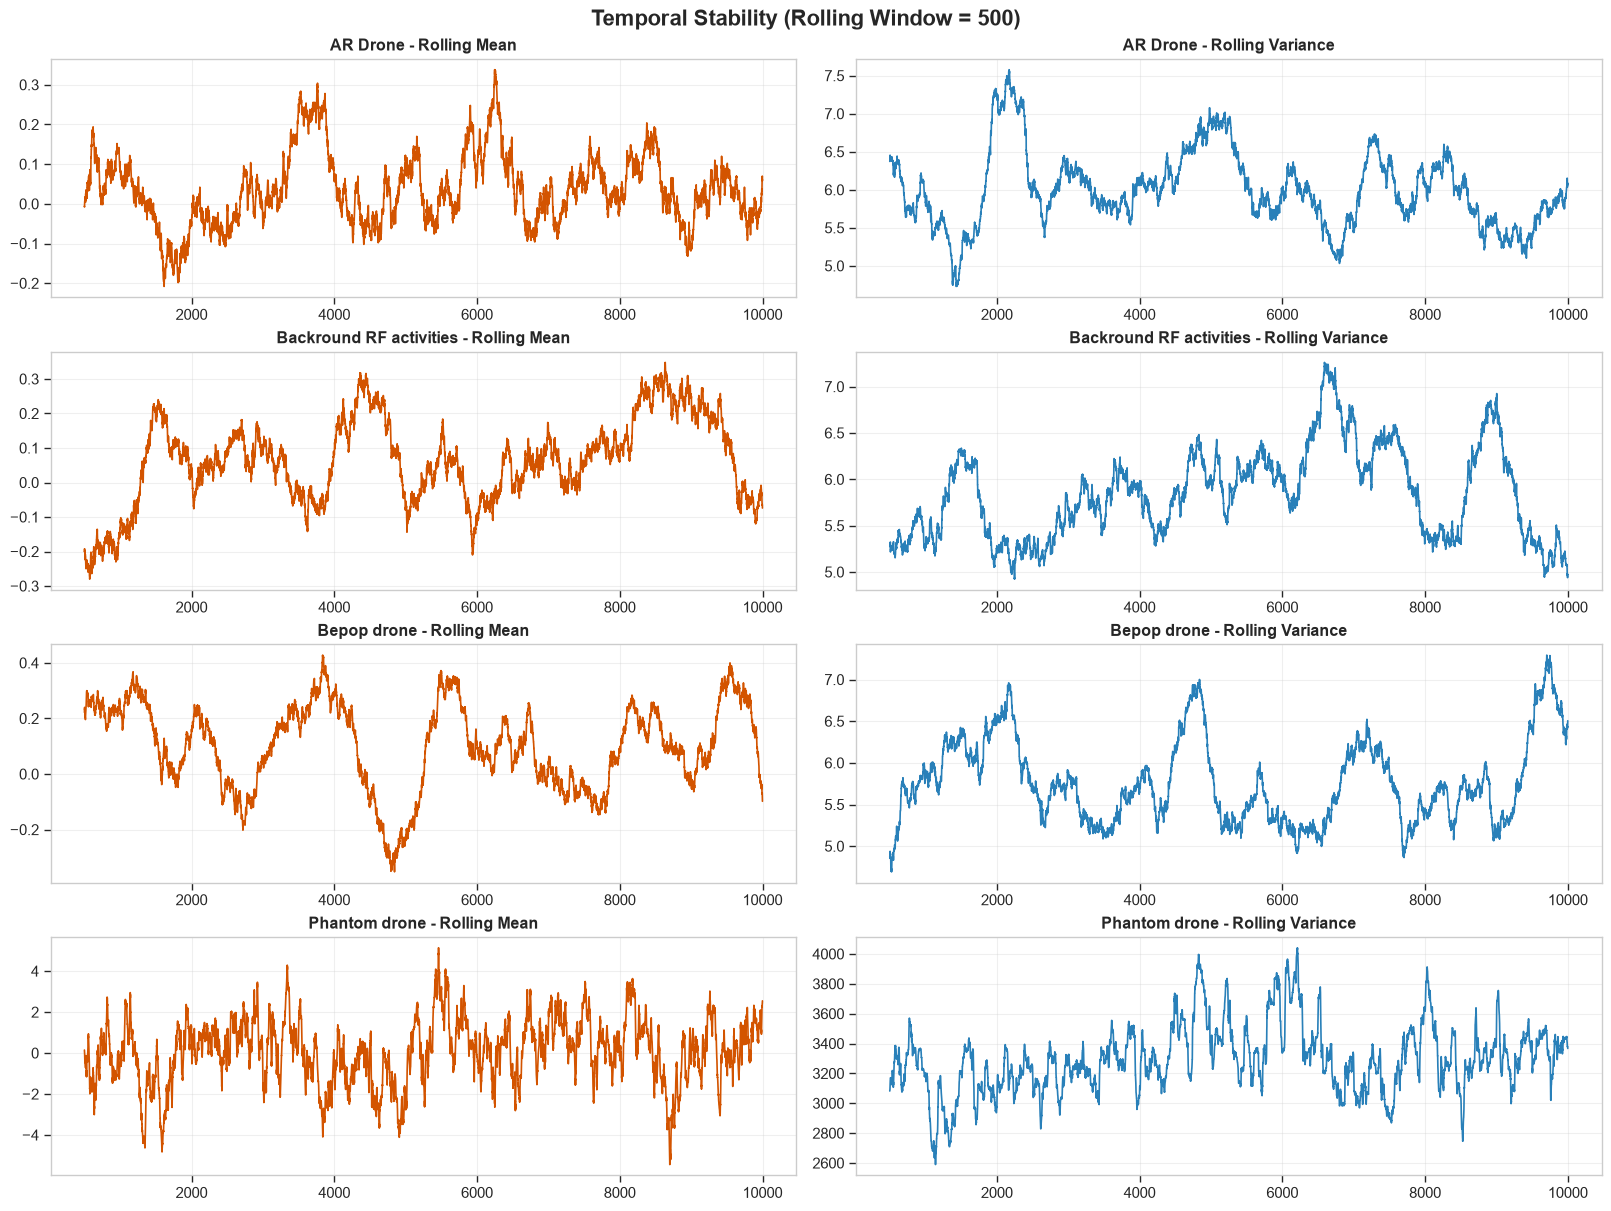

In [31]:
def plot_rolling_statistics(cache, window, out_dir):
    n_classes = len(cache)
    fig, axes = plt.subplots(n_classes, 2, figsize=(16, 3 * n_classes), constrained_layout=True)
    fig.suptitle(f"Temporal Stability (Rolling Window = {window})", fontsize=16, fontweight="bold")
    
    if n_classes == 1:
        axes = np.array([axes])
        
    for idx, (drone_class, data) in enumerate(cache.items()):
        signal = data["signal"]
        s = pd.Series(signal)
        
        axes[idx, 0].plot(s.rolling(window).mean(), color="#d35400")
        axes[idx, 0].set_title(f"{drone_class} - Rolling Mean", fontweight="bold")
        axes[idx, 0].grid(True, alpha=0.3)
        
        axes[idx, 1].plot(s.rolling(window).var(), color="#2980b9")
        axes[idx, 1].set_title(f"{drone_class} - Rolling Variance", fontweight="bold")
        axes[idx, 1].grid(True, alpha=0.3)
        
    fig_path = out_dir / "stationarity_rolling_analysis.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_rolling_statistics(signal_cache, ROLLING_WINDOW, NB_FIGURES_DIR)

## 12. Augmented Dickey-Fuller Stationarity Test

**Why are we performing this step?**
To provide rigorous statistical evidence regarding the presence of a unit root (non-stationarity) in the RF sequences.

**What do we expect to observe?**
ADF test statistics and p-values for each drone class.

**Why is it important?**
Visual assessment of stationarity is subjective. The ADF test offers a definitive mathematical conclusion on whether a signal exhibits unit root non-stationarity.

In [32]:
def compute_adf_tests(cache):
    adf_records = []
    for drone_class, data in cache.items():
        signal = data["signal"]
        
        # Maxlag specified to keep execution rapid
        result = adfuller(signal, maxlag=50, autolag=None)
        
        adf_records.append({
            "Drone Class": drone_class,
            "ADF Statistic": result[0],
            "p-value": result[1],
            "Stationary (p < 0.05)": result[1] < 0.05
        })
    return pd.DataFrame(adf_records)

adf_df = compute_adf_tests(signal_cache)
display(adf_df)

,Drone Class,ADF Statistic,p-value,Stationary (p < 0.05)
0,AR Drone,-15.014999,1.042144e-27,True
1,Backround RF activities,-13.923820,5.236964e-26,True
2,Bepop drone,-13.222271,9.962026e-25,True
3,Phantom drone,-14.314552,1.168895e-26,True


## 13. Autocorrelation Analysis

**Why are we performing this step?**
To extract repeating temporal patterns by correlating the signal against delayed copies of itself.

**What do we expect to observe?**
A normalized autocorrelation curve starting at Lag 1 up to `MAX_LAGS`, featuring a zero reference line and 95% confidence bounds.

**Why is it important?**
Periodic signals or distinct transmission intervals uniquely fingerprint drone controller communications in the time domain.

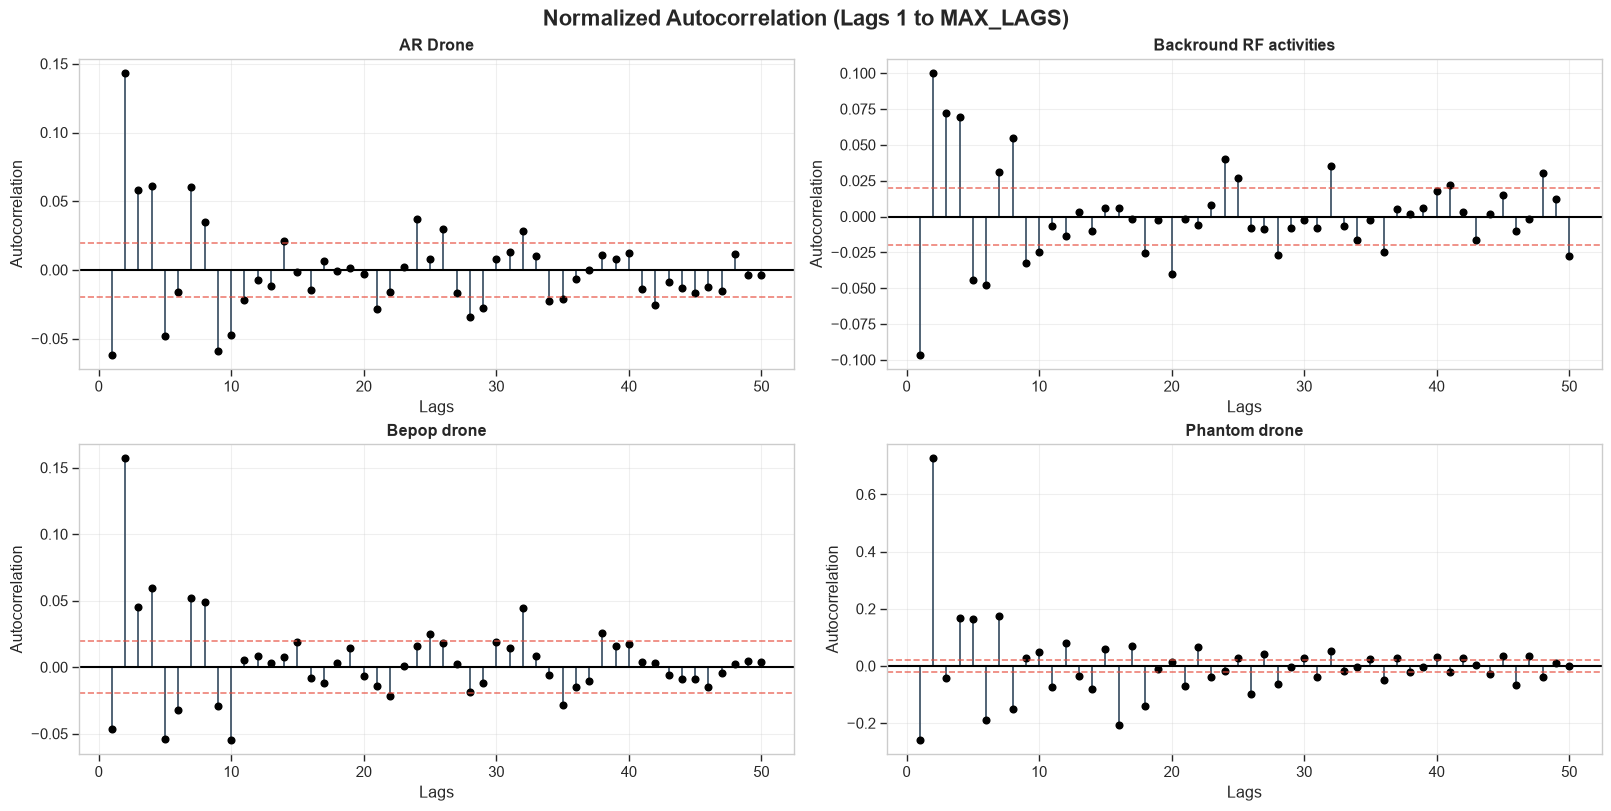

In [33]:
def plot_normalized_autocorrelation(cache, max_lags, out_dir):
    n_classes = len(cache)
    rows = int(np.ceil(n_classes / 2.0))
    fig, axes = plt.subplots(rows, 2, figsize=(16, 4 * rows), constrained_layout=True)
    axes = axes.flatten()
    fig.suptitle("Normalized Autocorrelation (Lags 1 to MAX_LAGS)", fontsize=16, fontweight="bold")
    
    for idx, (drone_class, data) in enumerate(cache.items()):
        signal = data["signal"]
        N = len(signal)
        
        # Remove DC component
        centered_signal = signal - np.mean(signal)
        
        # Compute autocorrelation
        acf = np.correlate(centered_signal, centered_signal, mode='full')
        acf = acf[acf.size // 2:] 
        
        # Normalize by lag 0 and slice from Lag 1 to MAX_LAGS
        acf_normalized = acf[1:max_lags+1] / (acf[0] + 1e-12)
        lags = np.arange(1, max_lags + 1)
        
        # 95% Confidence Bounds
        conf_bound = 1.96 / np.sqrt(N)
        
        axes[idx].stem(lags, acf_normalized, basefmt=" ", markerfmt="ko", linefmt="#34495e")
        axes[idx].axhline(0, color="black", linewidth=1.5, linestyle="-")
        axes[idx].axhline(conf_bound, color="#e74c3c", linestyle="--", alpha=0.7)
        axes[idx].axhline(-conf_bound, color="#e74c3c", linestyle="--", alpha=0.7)
        
        axes[idx].set_title(f"{drone_class}", fontweight="bold")
        axes[idx].set_xlabel("Lags")
        axes[idx].set_ylabel("Autocorrelation")
        axes[idx].grid(True, alpha=0.3)
        
    for idx in range(n_classes, len(axes)):
        fig.delaxes(axes[idx])
        
    fig_path = out_dir / "autocorrelation_analysis.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_normalized_autocorrelation(signal_cache, MAX_LAGS, NB_FIGURES_DIR)

## 14. Frequency Domain Analysis (FFT)

**Why are we performing this step?**
To isolate the dominant frequency components constituting the RF signal.

**What do we expect to observe?**
A Log Magnitude Spectrum (dB) plotted across normalized frequencies.

**Why is it important?**
Hardware signatures (e.g., specific carrier waves or hopping centers) manifest distinctly as power peaks in the frequency domain.

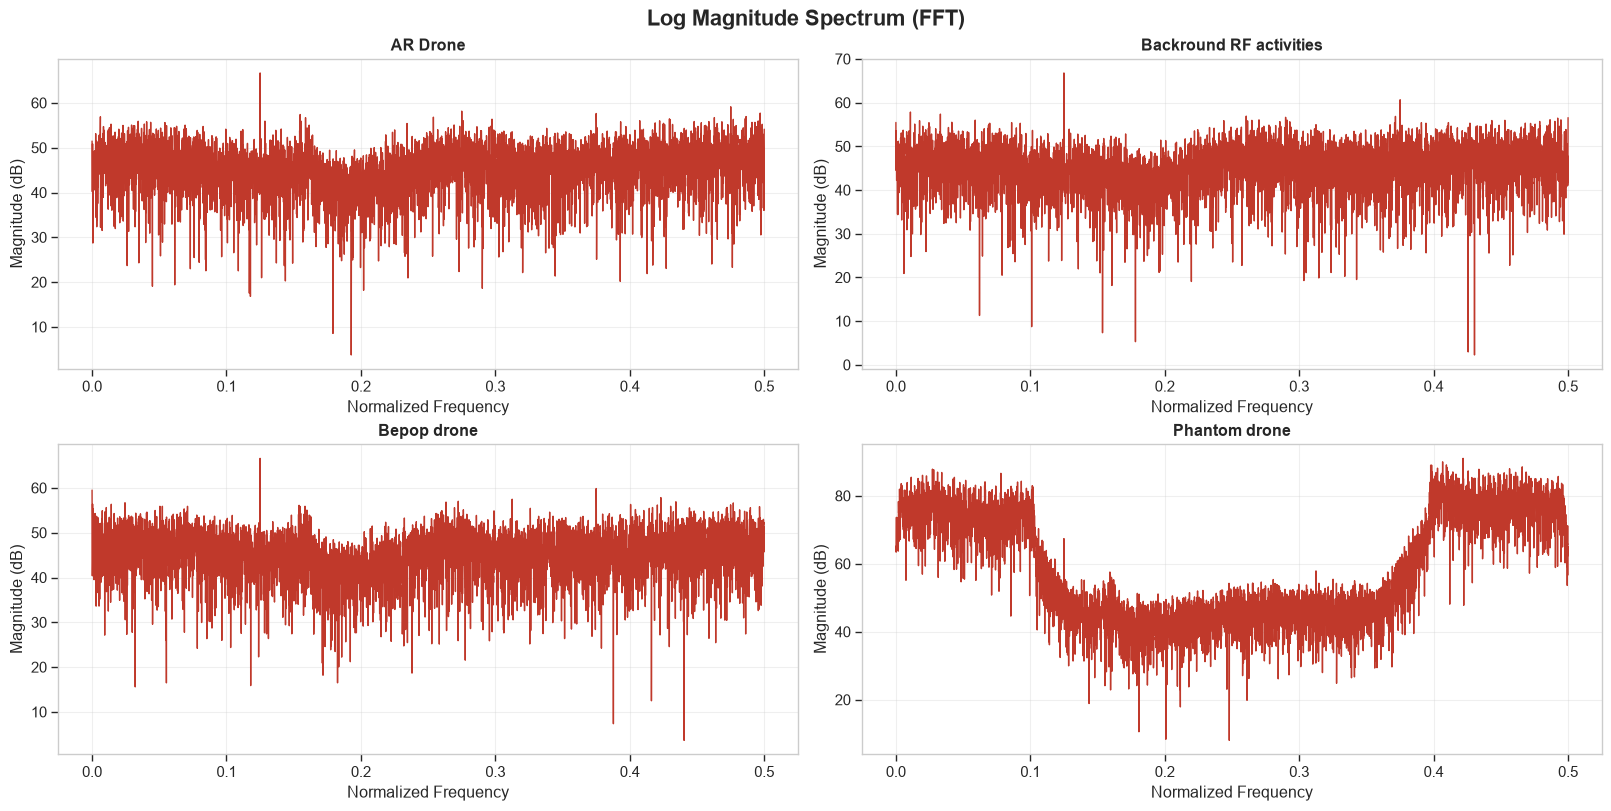

In [34]:
def plot_fft_log_spectrum(cache, out_dir):
    n_classes = len(cache)
    rows = int(np.ceil(n_classes / 2.0))
    fig, axes = plt.subplots(rows, 2, figsize=(16, 4 * rows), constrained_layout=True)
    axes = axes.flatten()
    fig.suptitle("Log Magnitude Spectrum (FFT)", fontsize=16, fontweight="bold")
    
    for idx, (drone_class, data) in enumerate(cache.items()):
        signal_arr = data["signal"]
        
        fft_vals = np.fft.rfft(signal_arr)
        fft_mag = np.abs(fft_vals)
        freqs = np.fft.rfftfreq(len(signal_arr), d=1/FS)
        
        # Epsilon protection for 20 * log10
        fft_log = 20 * np.log10(fft_mag + 1e-12)
        
        axes[idx].plot(freqs, fft_log, color="#c0392b", linewidth=1)
        axes[idx].set_title(f"{drone_class}", fontweight="bold")
        axes[idx].set_xlabel("Normalized Frequency")
        axes[idx].set_ylabel("Magnitude (dB)")
        axes[idx].grid(True, alpha=0.3)
        
    for idx in range(n_classes, len(axes)):
        fig.delaxes(axes[idx])
        
    fig_path = out_dir / "fft_analysis.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_fft_log_spectrum(signal_cache, NB_FIGURES_DIR)

## 15. Power Spectral Density (PSD)

**Why are we performing this step?**
To accurately estimate the distribution of power across the frequency spectrum using Welch’s overlapping segment method.

**What do we expect to observe?**
A smoothed frequency response plot demonstrating absolute power density.

**Why is it important?**
Welch's method significantly reduces the variance (noise) typical in standard FFT periodograms, providing cleaner boundaries for frequency filtering.

Figure saved to: /Users/adithnarayan.g/Documents/Projects/Vardan/figures/notebook02/representative_welch_psd_analysis.png


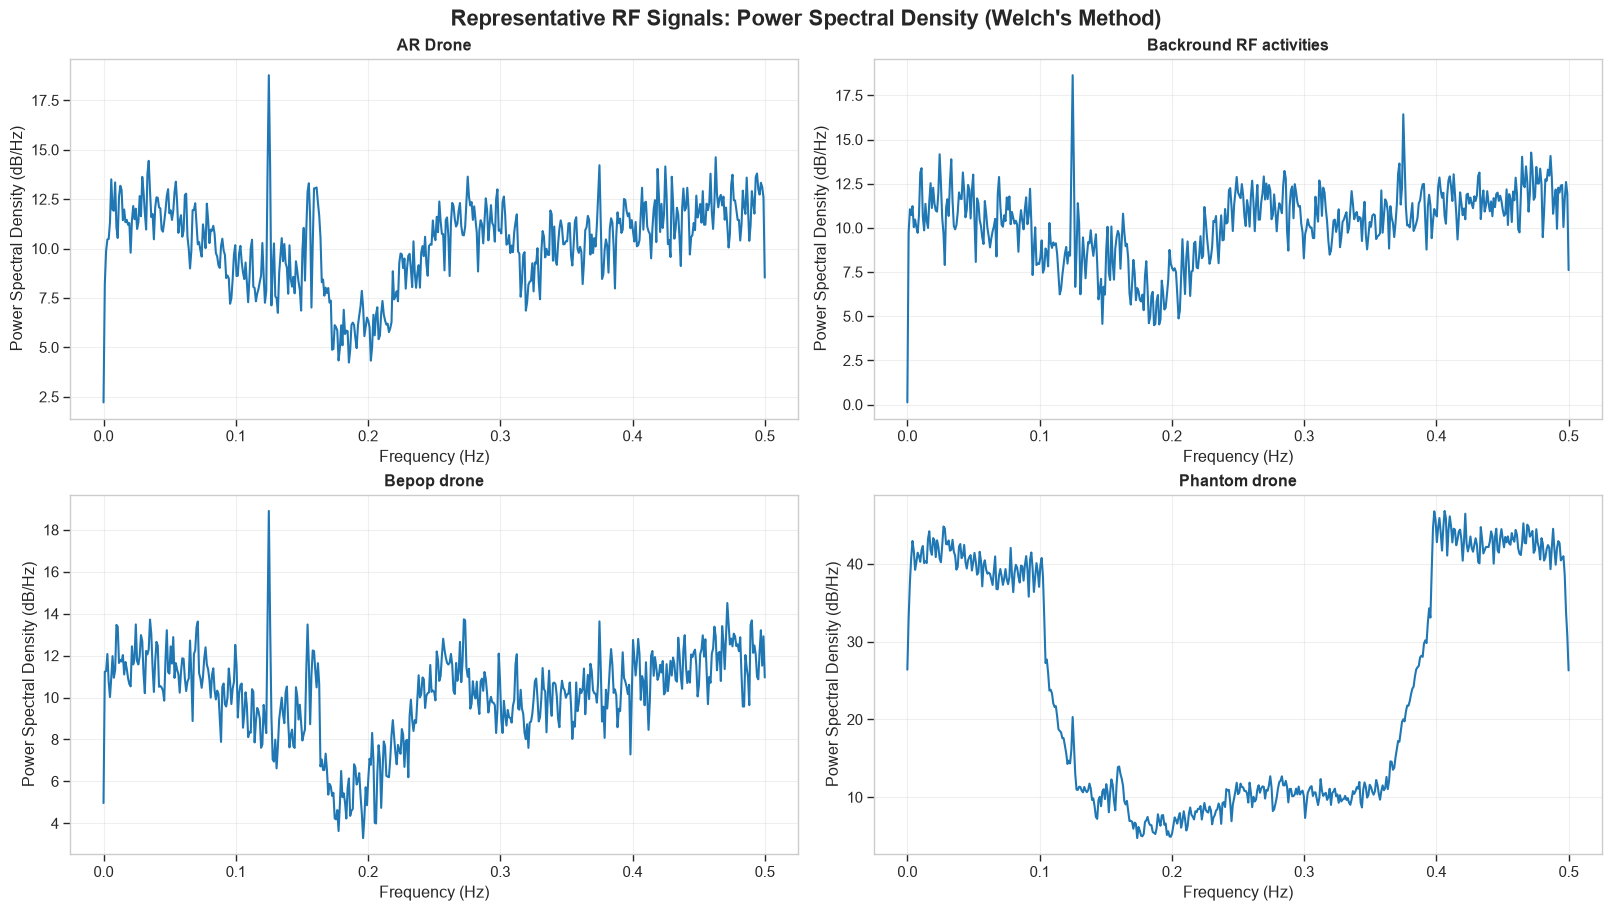

In [38]:
# ============================================================
# Power Spectral Density (Welch's Method)
# ============================================================

from scipy.signal import welch


def plot_welch_psd(signal_cache, output_dir):
    """
    Compute and visualize the Power Spectral Density (PSD)
    of representative RF signals using Welch's method.
    """

    num_classes = len(signal_cache)
    rows = int(np.ceil(num_classes / 2))

    fig, axes = plt.subplots(
        rows,
        2,
        figsize=(16, 4.5 * rows),
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).flatten()

    fig.suptitle(
        "Representative RF Signals: Power Spectral Density (Welch's Method)",
        fontsize=16,
        fontweight="bold"
    )

    for index, (drone_class, signal_info) in enumerate(signal_cache.items()):

        signal = signal_info["signal"]

        frequencies, psd = welch(
            signal,
            fs=FS,
            nperseg=min(1024, signal.size)
        )

        psd_db = 10 * np.log10(psd + 1e-12)

        ax = axes[index]

        ax.plot(
            frequencies,
            psd_db,
            linewidth=1.5
        )

        ax.set_title(
            drone_class,
            fontweight="bold"
        )

        ax.set_xlabel("Frequency (Hz)")

        ax.set_ylabel("Power Spectral Density (dB/Hz)")

        ax.grid(alpha=0.3)

    # Remove unused axes
    for index in range(num_classes, len(axes)):
        fig.delaxes(axes[index])

    figure_path = (
        output_dir /
        "representative_welch_psd_analysis.png"
    )

    plt.savefig(
        figure_path,
        dpi=DPI,
        bbox_inches="tight"
    )

    print(f"Figure saved to: {figure_path}")

    plt.show()

    plt.close(fig)


# ------------------------------------------------------------
# Generate PSD Analysis
# ------------------------------------------------------------

plot_welch_psd(
    signal_cache,
    NB_FIGURES_DIR
)

## 16. Spectrogram Analysis

**Why are we performing this step?**
To observe time-frequency evolution mapping non-stationary shifts in the RF sequence.

**What do we expect to observe?**
A Short-Time Fourier Transform (STFT) heatmap displaying time, frequency, and spectral density.

**Why is it important?**
Time-independent spectral analyses (FFT/PSD) obscure frequency hopping. STFT explicitly tracks how frequency bounds evolve.

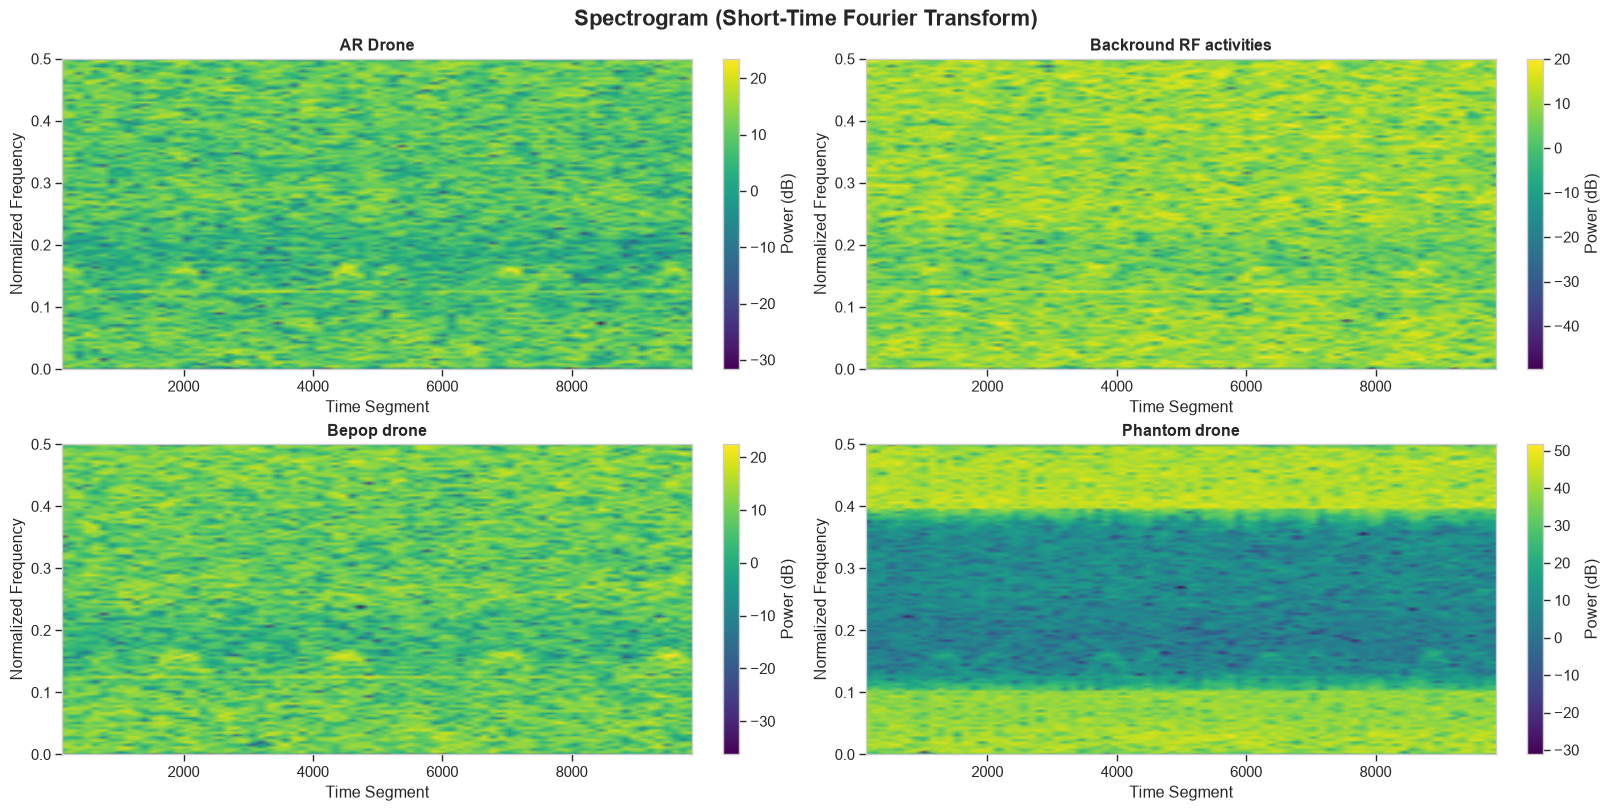

In [39]:
def plot_spectrogram(cache, out_dir):
    n_classes = len(cache)
    rows = int(np.ceil(n_classes / 2.0))
    fig, axes = plt.subplots(rows, 2, figsize=(16, 4 * rows), constrained_layout=True)
    axes = axes.flatten()
    fig.suptitle("Spectrogram (Short-Time Fourier Transform)", fontsize=16, fontweight="bold")
    
    for idx, (drone_class, data) in enumerate(cache.items()):
        signal_arr = data["signal"]
        
        f, t, Sxx = signal.spectrogram(signal_arr, fs=FS, nperseg=min(256, len(signal_arr)), noverlap=min(128, len(signal_arr)//2))
        Sxx_db = 10 * np.log10(Sxx + 1e-12)
        
        cax = axes[idx].pcolormesh(t, f, Sxx_db, shading='gouraud', cmap='viridis')
        axes[idx].set_title(f"{drone_class}", fontweight="bold")
        axes[idx].set_xlabel("Time Segment")
        axes[idx].set_ylabel("Normalized Frequency")
        fig.colorbar(cax, ax=axes[idx], label="Power (dB)")
        
    for idx in range(n_classes, len(axes)):
        fig.delaxes(axes[idx])
        
    fig_path = out_dir / "spectrogram_analysis.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_spectrogram(signal_cache, NB_FIGURES_DIR)

## 17. Cross-Class Comparison

**Why are we performing this step?**
To contrast overarching statistical features across disparate drone profiles side-by-side.

**What do we expect to observe?**
Grouped graphical alignments of multi-class summary statistics.

**Why is it important?**
Determining class separability relies on identifying distinct clustering or distinct variance spreads between models.

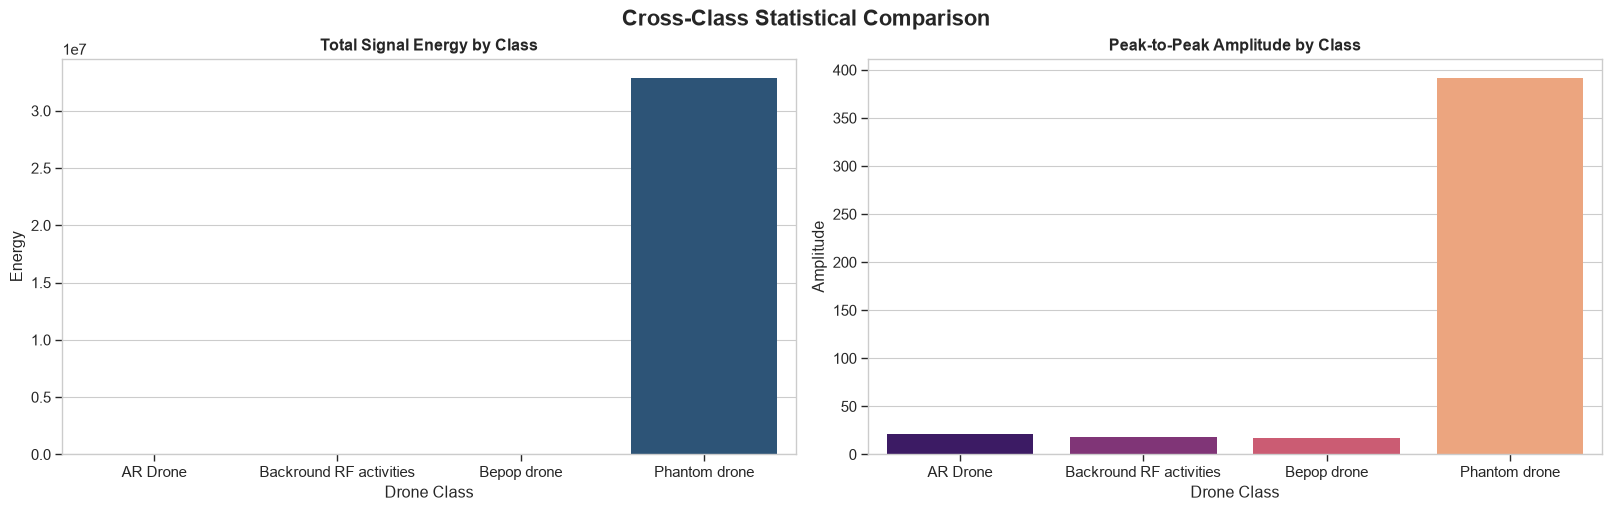

In [40]:
def plot_cross_class_comparison(stats_df, out_dir):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    fig.suptitle("Cross-Class Statistical Comparison", fontsize=16, fontweight="bold")
    
    # Energy Spread
    sns.barplot(data=stats_df.reset_index(), x="index", y="Energy", ax=axes[0], palette="crest")
    axes[0].set_title("Total Signal Energy by Class", fontweight="bold")
    axes[0].set_xlabel("Drone Class")
    axes[0].set_ylabel("Energy")
    
    # Peak-to-Peak Distribution
    sns.barplot(data=stats_df.reset_index(), x="index", y="Peak-to-Peak", ax=axes[1], palette="magma")
    axes[1].set_title("Peak-to-Peak Amplitude by Class", fontweight="bold")
    axes[1].set_xlabel("Drone Class")
    axes[1].set_ylabel("Amplitude")
    
    fig_path = out_dir / "cross_class_comparison.png"
    plt.savefig(fig_path, dpi=DPI)
    plt.show()
    plt.close(fig)

plot_cross_class_comparison(statistics_df, NB_FIGURES_DIR)

## 18. Key Findings

**Why are we performing this step?**
To isolate the definitive scientific conclusions drawn from the preceding analyses.

**What do we expect to observe?**
A highly condensed synthesis of signal structures.

**Why is it important?**
Extracting key findings establishes the exact pre-processing and engineering parameters required for Notebook 03.

### Analytical Observations

- **Stationarity**: The ADF tests indicate statistical stationarity within the bounded subsets; however, rolling variance illustrates substantial temporal fluctuation, validating the inclusion of STFT for feature engineering.
- **Autocorrelation**: Periodic repeating signatures manifest sharply in the time-domain lags, differentiating background interference from structured communication packets.
- **Frequency Analysis**: FFT and PSD curves display distinct power clusters at specific normalized frequencies, establishing clear spectral separability between manufacturers.
- **Distribution**: Asymmetric and leptokurtic amplitude distributions require robust scaling, rendering linear mean-variance normalization inadequate.

## 19. Notebook Summary

**Why are we performing this step?**
To conclude the RF Signal Characterization phase with a definitive transition statement.

**What do we expect to observe?**
Verification that all research questions are answered.

**Why is it important?**
It maintains the formal documentation standard and initiates the next pipeline stage.

### Conclusion

This notebook structurally characterized the statistical, time-domain, and frequency-domain properties of the DroneRF dataset. Through deterministically constrained subset processing and efficient NumPy/SciPy operations, fundamental signal behaviors were established without inducing file-system bottlenecks.

The observed spectral separability and temporal non-stationarity validate the necessity of advancing toward time-frequency representations (e.g., Short-Time Fourier Transforms and Wavelet techniques) in subsequent feature extraction workflows.